# Analysis for Task 3 and 5 

In [1]:
import polars as pl
import pandas as pd
import pymc as pm
import arviz as az
import arviz_plots as azp

**Note to self**: `arviz` is going through some refactoring changes ... might want to use [`arviz-plots`](https://github.com/arviz-devs/arviz-plots) ([documentations](https://python.arviz.org/projects/plots/en/latest/)) instead. 

In [27]:
# read in data 
task5_df = pl.read_csv("../data/processed/task5.csv")
task3_df = pl.read_csv("../data/processed/task3.csv")

## Task 5 -- Error on X-Axis 

We want to implement the following model in PyMC: 

$$
\begin{align}
\texttt{error}_i &\sim \mathcal{N}(\mu_{\text{PID}[i]}, \sigma_{i, \text{PID}[i]}) \\ 
\mu_j &\sim \mathcal{N}(\overline{\mu}, \overline{\sigma}^2)\\ 
\log(\sigma_{i, j}) &= \alpha_j + \log(\texttt{va.ans.y}_i) \\ 
\alpha_j &\sim N(\mu_\alpha, \sigma_\alpha) \\ 
\mu_\alpha, \bar{\mu} &\sim N(0, 1) \\ 
\sigma_\alpha, \bar{\sigma} &\sim \text{Half-Cauchy}(\mu=0, \beta=1)
\end{align}
$$

- [`pymc.HalfCauchy`](https://www.pymc.io/projects/docs/en/latest/api/distributions/generated/pymc.HalfCauchy.html) --- note that this is the **standard half-cauchy** distribution (i.e., distribution starts at 0 and extends to $+\infty$ and NOT a shifted cauchy distribution). For our case we simply don't need to specify $mu = 0$. 

In [28]:
# prepare data 
# first filter out those data that we will NOT use to fit the model
# task 5 excludes analysis from two participants who were using the slider in a wrong way ... 
task5_x_exclude = ["667433338e6cc9e53c828774", "67e2f5ebbe69a58c40a5d550"]
task5_df = task5_df.filter(~pl.col('participantId').is_in(task5_x_exclude))
va_dist = task5_df.select("va.ans.y").to_numpy().flatten()
obv_error = (task5_df.select("va.select.x") - task5_df.select("va.ans.x")).to_numpy().flatten()

In [29]:
# create participant index mapping (for hierarchical modeling)
participant_ids = task5_df.select("participantId").to_numpy().flatten()
participant_idx, unique_participants = pd.factorize(participant_ids)

In [30]:
with pm.Model(coords={
    "participant": unique_participants
}) as task_5_x_model: 
    # hyperpriors 
    mu_bar = pm.Normal("mu_bar", 0, 1)
    mu_alpha = pm.Normal("mu_alpha", 0, 1)
    sigma_bar = pm.HalfCauchy("sigma_bar", 1)
    sigma_alpha = pm.HalfCauchy("sigma_alpha", 1)

    # data 
    va = pm.Data("va_dist", va_dist)
    participant_idx_data = pm.Data("participant_idx", participant_idx)

    # participant-level intercept 
    alpha = pm.Normal("alpha", mu_alpha, sigma_alpha, dims="participant")
    log_sigma = alpha[participant_idx_data] + pm.math.log(va)
    sigma = pm.math.exp(log_sigma)

    mu = pm.Normal("mu", mu_bar, sigma_bar, dims="participant")

    # likelihood 
    error = pm.Normal("error", mu[participant_idx_data], sigma, observed=obv_error)


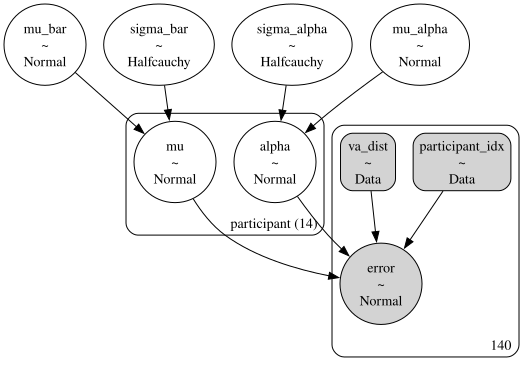

In [31]:
task_5_x_model
pm.model_to_graphviz(task_5_x_model)

In [ ]:
# fit the model 
with task_5_x_model:
    task_5_idata = pm.sample(
        draws=3000,
        tune=3000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed = 42, 
        progressbar=False
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_bar, mu_alpha, sigma_bar, sigma_alpha, alpha, mu]
Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 4 seconds.


In [41]:
# posterior predictive check 
with task_5_x_model:
    pm.sample_posterior_predictive(task_5_idata, extend_inferencedata=True)

Sampling: [error]


Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00━━━━━━━━━━━━━━  54% 0:00:01 / 0:00:00


In [42]:
az.summary(task_5_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_bar,0.021,0.011,-0.000,0.043,0.000,0.000,15577.0,8862.0,1.0
mu_alpha,-4.354,0.123,-4.588,-4.126,0.001,0.002,10517.0,6933.0,1.0
alpha[67f03733938aa3f0d17ce8a8],-4.188,0.201,-4.552,-3.814,0.002,0.002,13500.0,7820.0,1.0
alpha[5c8f2ac8d7ecab0018d529aa],-4.619,0.225,-5.039,-4.198,0.002,0.002,14220.0,9402.0,1.0
alpha[6740e1e09ca406ab781318cb],-4.381,0.204,-4.750,-3.992,0.001,0.002,19952.0,8584.0,1.0
alpha[67e557aa25a43e8dde6c806c],-4.644,0.230,-5.091,-4.234,0.002,0.002,15794.0,9070.0,1.0
alpha[67f441842da280dba751a76b],-4.397,0.207,-4.776,-4.009,0.002,0.002,17631.0,7979.0,1.0
alpha[67f9736009c0ccdd5034f448],-3.852,0.209,-4.238,-3.468,0.002,0.002,9247.0,8126.0,1.0
alpha[67fbed03e8c70e38014c41b3],-4.658,0.228,-5.083,-4.236,0.002,0.002,13380.0,9067.0,1.0
alpha[558d8d71fdf99b534f79b352],-4.187,0.190,-4.530,-3.819,0.002,0.002,17065.0,7626.0,1.0


array([[<Axes: title={'center': 'mu_bar'}>,
        <Axes: title={'center': 'mu_bar'}>],
       [<Axes: title={'center': 'mu_alpha'}>,
        <Axes: title={'center': 'mu_alpha'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'sigma_bar'}>,
        <Axes: title={'center': 'sigma_bar'}>],
       [<Axes: title={'center': 'sigma_alpha'}>,
        <Axes: title={'center': 'sigma_alpha'}>]], dtype=object)

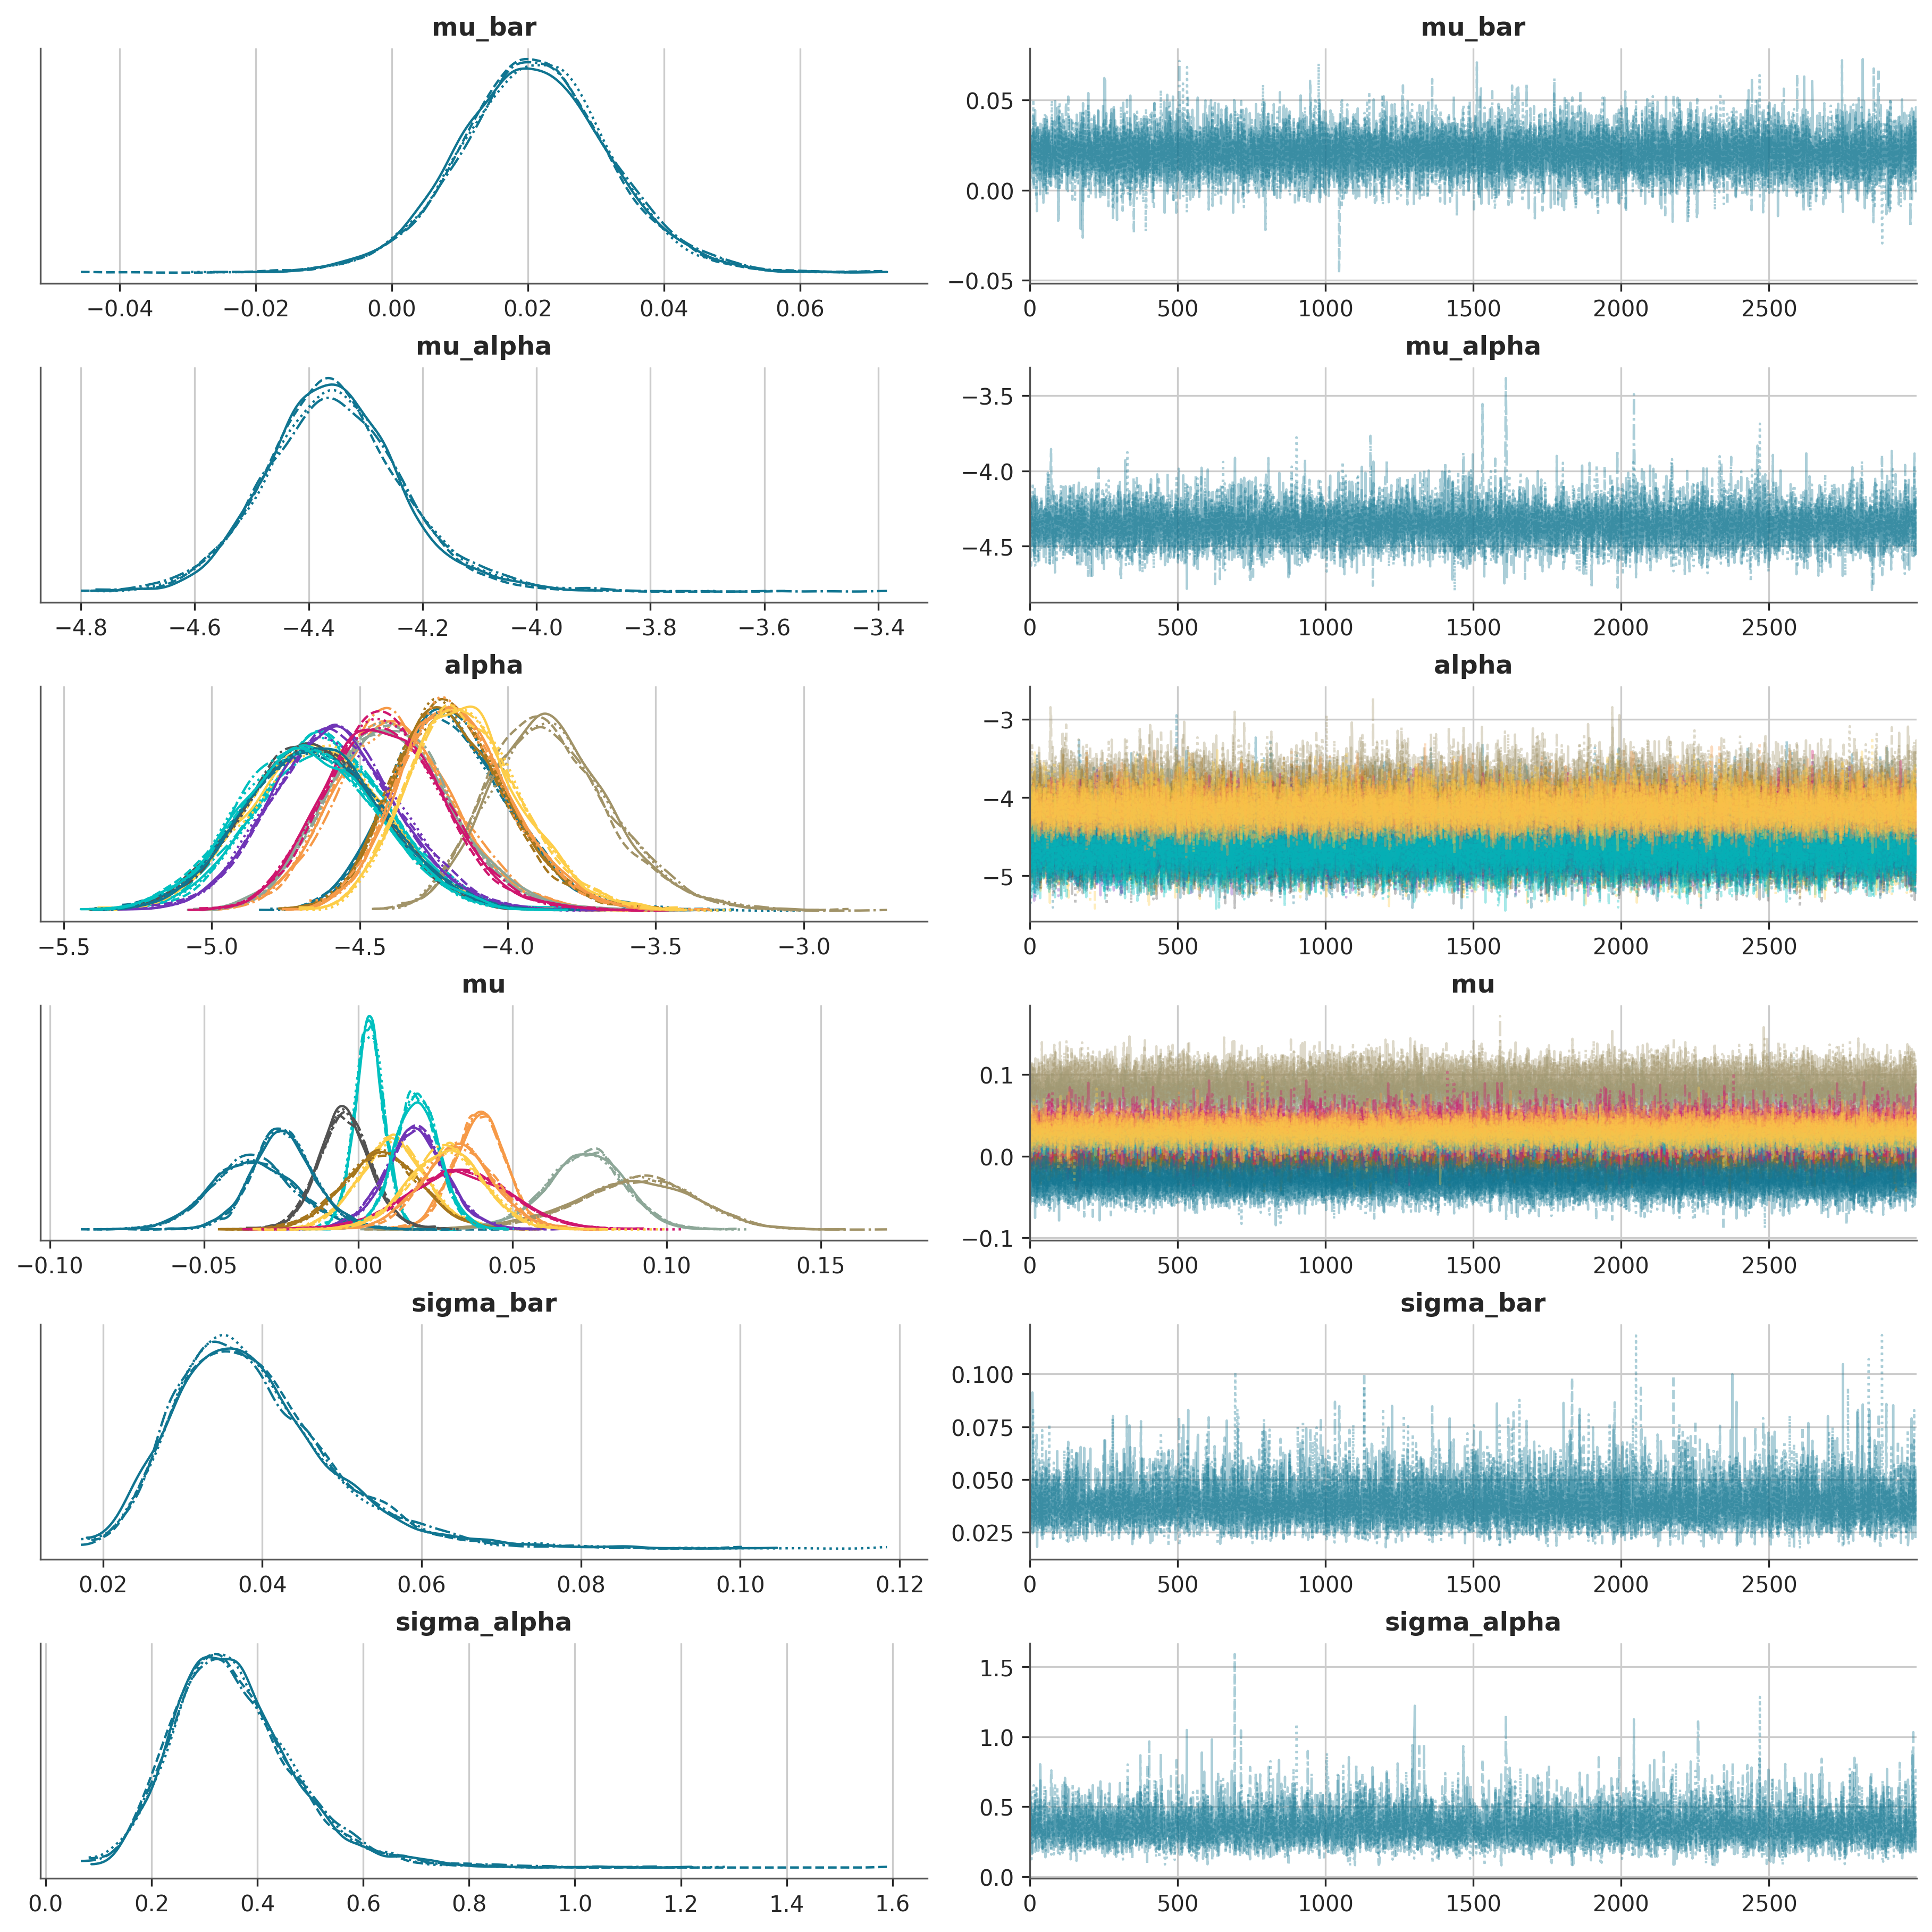

In [43]:
az.plot_trace(task_5_idata)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

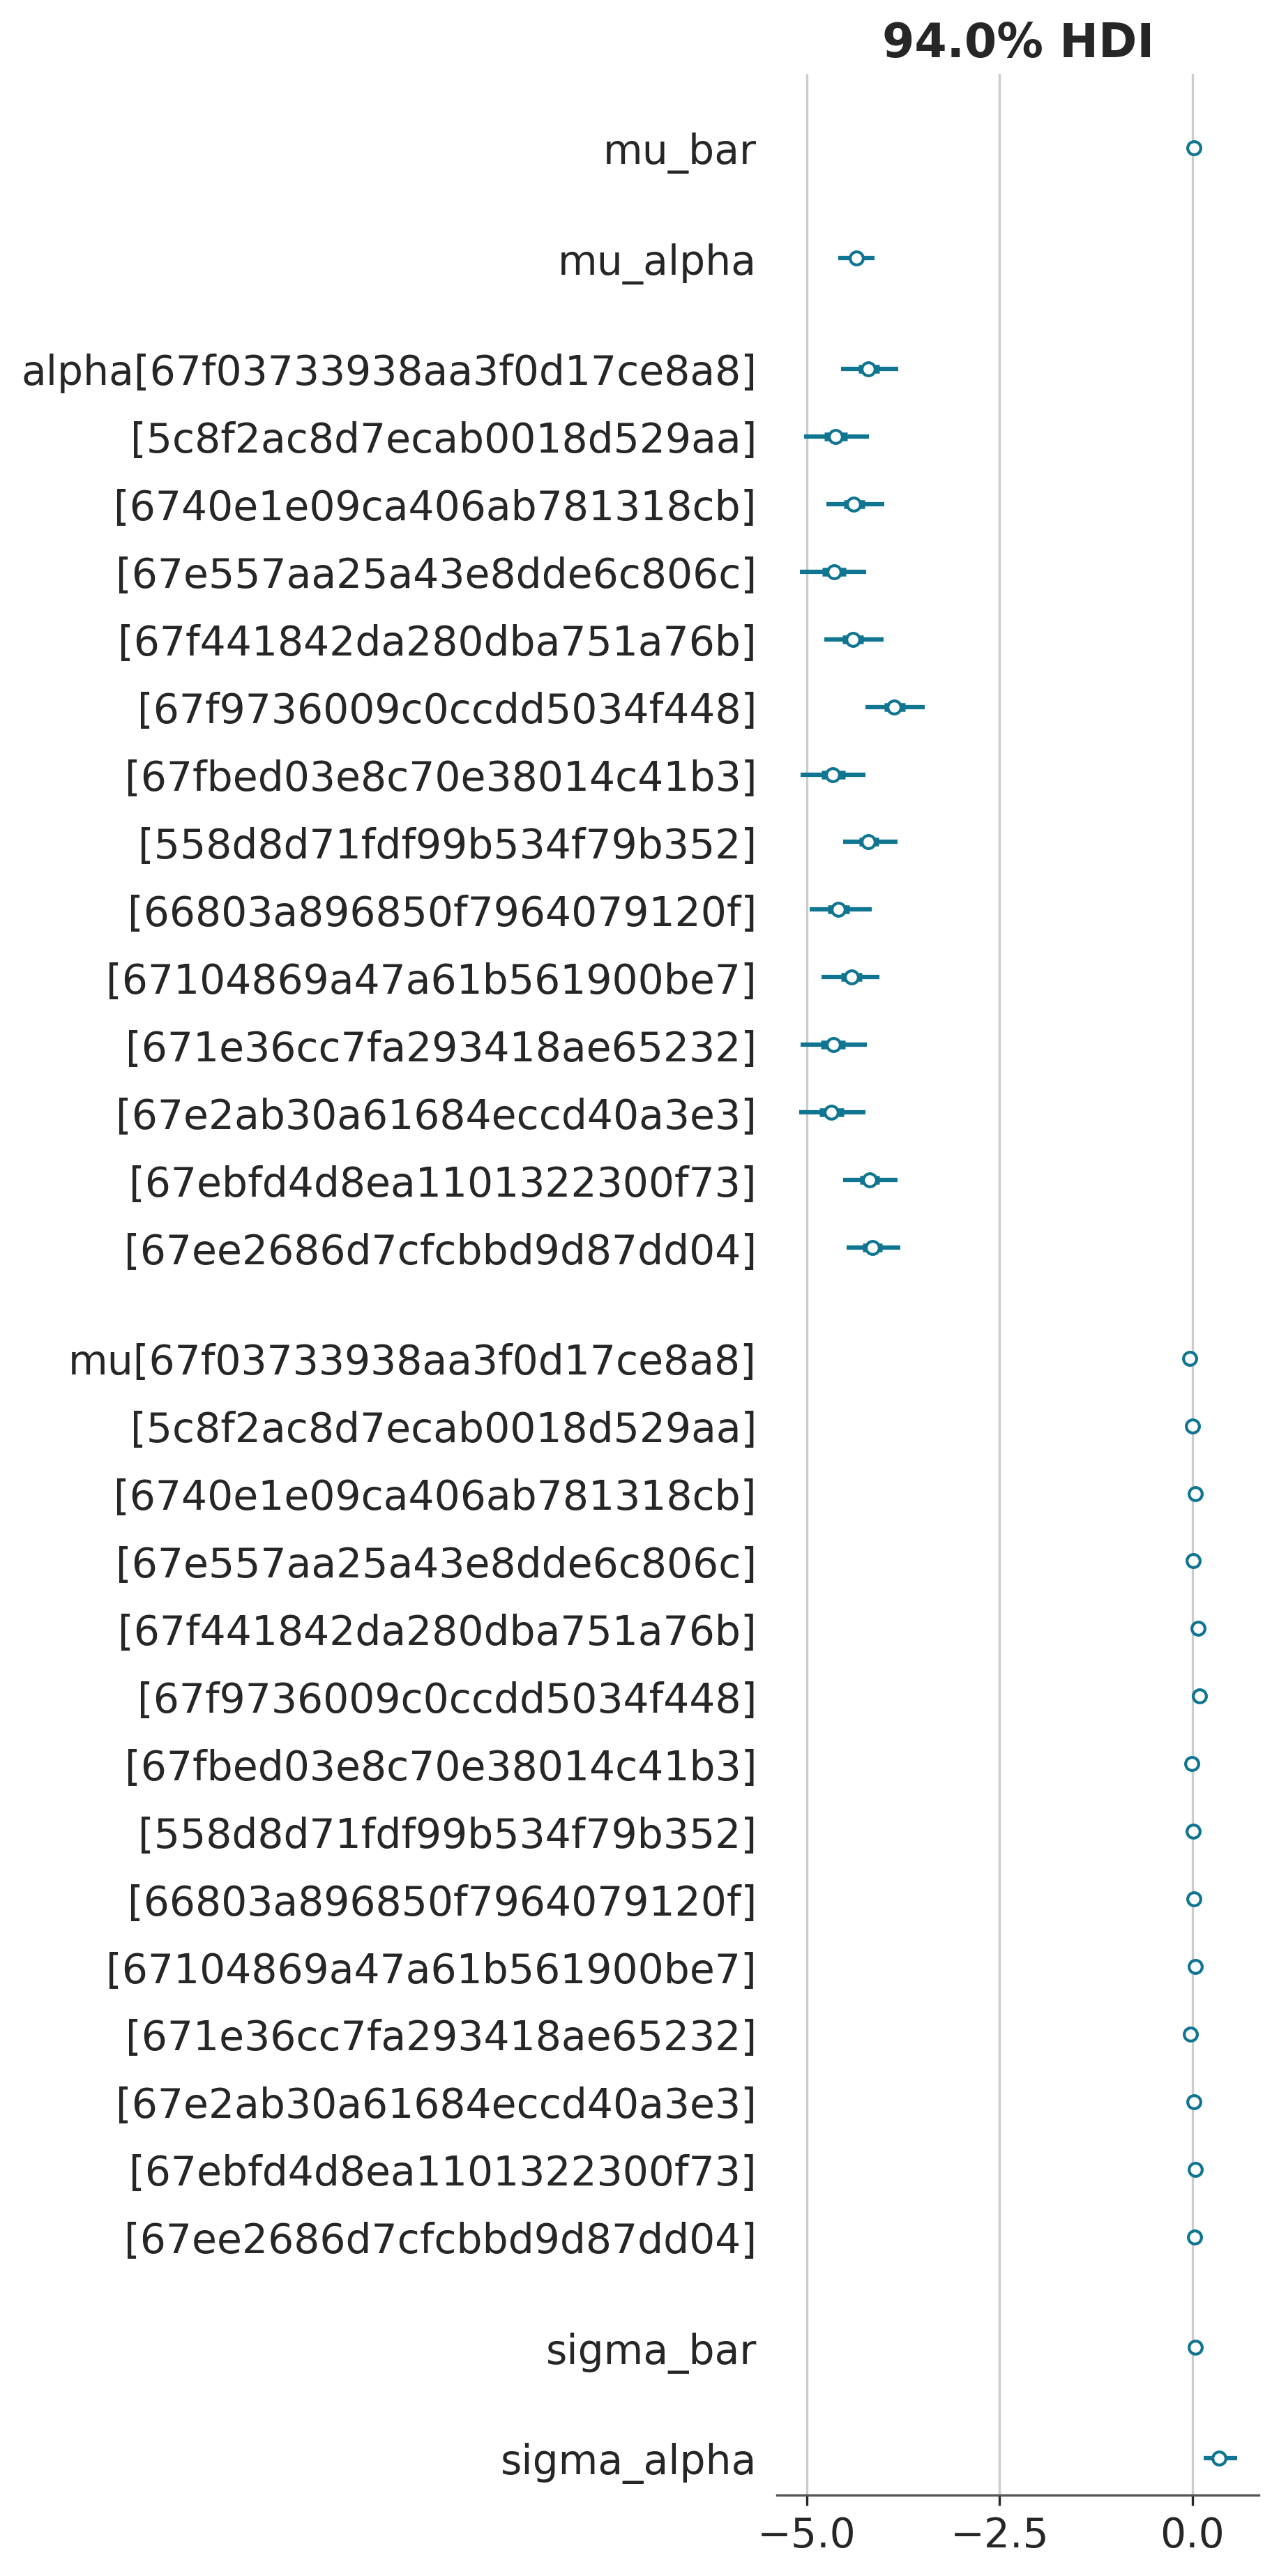

In [44]:
az.plot_forest(task_5_idata, combined=True)

I have to say ... the names could use more work ... right now it's not the most intuitive ... 

In [45]:
task_5_idata

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data
	> constant_data

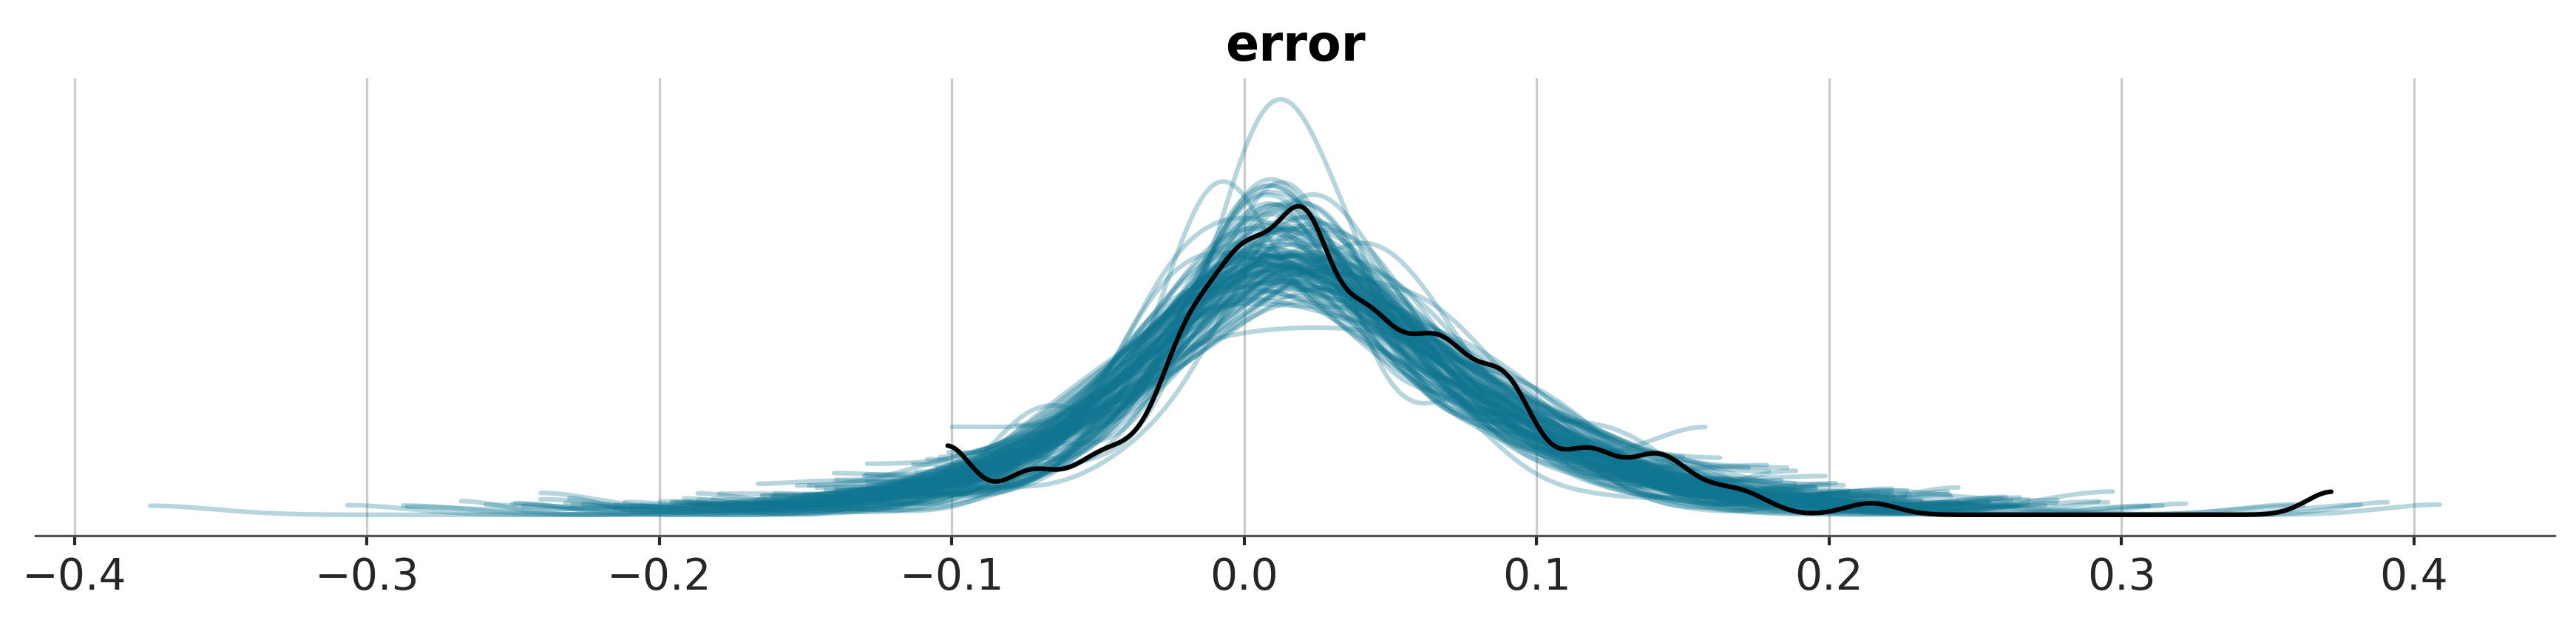

In [46]:
az.style.use("arviz-docgrid")
pc = azp.plot_ppc_dist(
    task_5_idata,
    num_samples=100,
    # backend="none",
)
pc.show()

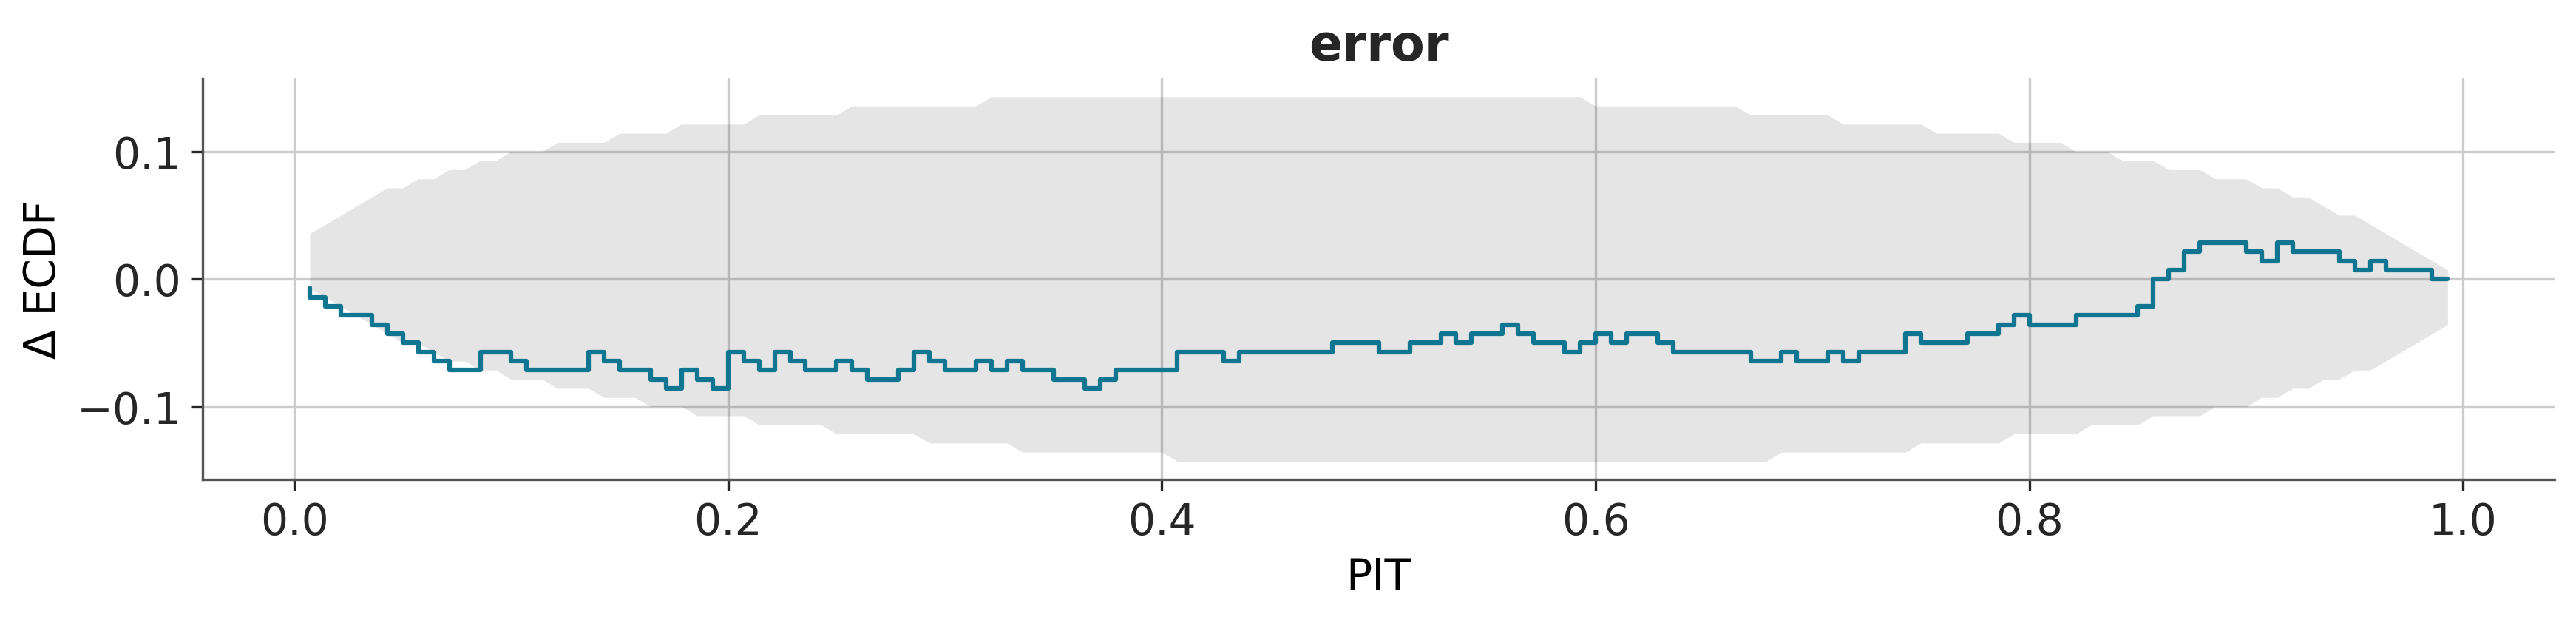

In [47]:
az.style.use("arviz-docgrid")
pc = azp.plot_ppc_pit(
    task_5_idata,
)
pc.show()

In [48]:
# save fitted model 
task_5_idata.to_netcdf(filename="../fitted_models/task5.x.nc")

'../fitted_models/task5.x.nc'

## Task 5 -- Error on Y-axis 

In [ ]:
# TODO 
# with pm.Model() as task_5_y_model: 
    # TODO 

## Task 3

In [72]:
# this is the data set we're dealing with: 
task3_df.head(5)

,participantId,task,id,rsp_time,status,data.select.x,data.select.y,pixel.select.x,pixel.select.y,param.mu,param.sigma,param.lambda,param.p,param.q,pixelToMM,dist_to_screen,phy.select.x,phy.select.y,va.select.x,va.select.y,data.ans.y,data.ans.x,pixel.ans.x,pixel.ans.y,phy.ans.x,phy.ans.y,va.ans.x,va.ans.y
i64,str,str,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,"""67f03733938aa3f0d17ce8a8""","""task3""",1,8.633,"""completed""",0.43,0.500188,340.505,212.425546,0.15,0.51,0.38,3.17,13.54,4.6,668.258963,63.153261,42.950968,5.410666,3.681301,0.5,0.42972,340.490012,212.5,63.150003,42.934783,5.410387,3.679915
2,"""67f03733938aa3f0d17ce8a8""","""task3""",2,17.708,"""completed""",1.45,0.500799,395.075,212.184367,1.96,0.53,-0.64,4.67,3.43,4.6,668.258963,75.016304,43.003398,6.425073,3.685792,0.5,1.448713,395.006146,212.5,75.001336,42.934783,6.423794,3.679915
3,"""67f03733938aa3f0d17ce8a8""","""task3""",3,11.207,"""completed""",-0.2,0.512043,306.8,207.74295,-0.42,1.44,0.08,3.81,2.61,4.6,668.258963,55.826087,43.968924,4.783686,3.768487,0.5,-0.250912,304.076198,212.5,55.233956,42.934783,4.733005,3.679915
4,"""67f03733938aa3f0d17ce8a8""","""task3""",4,11.814,"""completed""",1.55,0.492127,400.425,215.609692,1.86,0.51,-0.41,3.53,3.42,4.6,668.258963,76.179348,42.258763,6.524473,3.622013,0.5,1.561565,401.043751,212.5,76.313859,42.934783,6.535968,3.679915
5,"""67f03733938aa3f0d17ce8a8""","""task3""",5,10.115,"""completed""",0.38,0.51417,337.83,206.902846,0.62,0.58,-0.29,4.61,28.53,4.6,668.258963,62.571739,44.151555,5.360917,3.784129,0.5,0.353994,336.438654,212.5,62.269273,42.934783,5.33504,3.679915


Math model for task 3: 

$$
\begin{align*}
\texttt{error}_i &\sim \mathcal{N}(0, \sigma_{i, \text{PID}[i]}) \\ 
\log(\sigma_{i, j}) &= \alpha_j + \log(\texttt{va.ans.x}_i) \\ 
\alpha_j &\sim N(\mu_\alpha, \sigma_\alpha) \\ 
\mu_\alpha &\sim N(0, 1) \\ 
\sigma_\alpha &\sim \text{Half-Cauchy}(0, 1)
\end{align*}
$$

In [73]:
# prepare data 
error_va = (task3_df.select("va.select.y") - task3_df.select("va.ans.y")).to_numpy().flatten()
va_dist = task3_df.select("va.ans.x").to_numpy().flatten()

In [74]:
# create participant index mapping (for hierarchical modeling)
participant_ids = task3_df.select("participantId").to_numpy().flatten()
participant_idx, unique_participants = pd.factorize(participant_ids)

In [49]:
with pm.Model(coords={
    "participant": unique_participants
}) as task_3_model:
    # hyperpriors 
    sigma_alpha = pm.HalfCauchy("sigma_alpha", 1)
    mu_alpha = pm.Normal("mu_alpha", 0, 1)

    # participant-level intercept 
    alpha = pm.Normal("alpha", mu_alpha, sigma_alpha, dims="participant")
    
    # observation level variance 
    va = pm.Data("vis_angle", va_dist)
    log_sigma = alpha[participant_idx] + pm.math.log(va)
    sigma = pm.math.exp(log_sigma)

    # likelihood 
    error = pm.Normal("error", 0, sigma, observed=error_va)

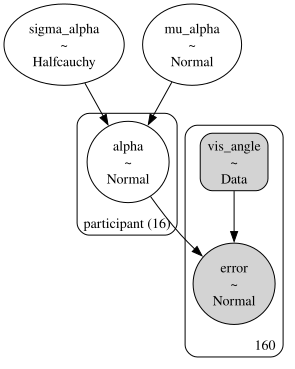

In [ ]:
# check to verify that this is the model that we want 
task_3_model
pm.model_to_graphviz(task_3_model)

In [63]:
# fit the model 
with task_3_model:
    task_3_trace = pm.sample(
        draws = 3000,
        tune=3000,
        chains=4,
        cores=4,
        random_seed = 42, 
        progressbar=False
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_alpha, mu_alpha, alpha]
Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 1 seconds.


In [64]:
task_3_trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [65]:
az.summary(task_3_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-4.207,0.135,-4.457,-3.951,0.001,0.001,16357.0,10531.0,1.0
alpha[67f03733938aa3f0d17ce8a8],-4.135,0.204,-4.501,-3.739,0.001,0.002,22889.0,7442.0,1.0
alpha[5c8f2ac8d7ecab0018d529aa],-3.776,0.196,-4.123,-3.397,0.001,0.002,21048.0,8731.0,1.0
alpha[6740e1e09ca406ab781318cb],-4.500,0.217,-4.891,-4.091,0.001,0.002,23682.0,8523.0,1.0
alpha[67e557aa25a43e8dde6c806c],-4.414,0.215,-4.812,-4.010,0.002,0.002,20757.0,8072.0,1.0
alpha[67f441842da280dba751a76b],-3.857,0.195,-4.211,-3.483,0.001,0.002,19490.0,8296.0,1.0
alpha[67f9736009c0ccdd5034f448],-4.145,0.201,-4.508,-3.764,0.001,0.002,21276.0,8737.0,1.0
alpha[67fbed03e8c70e38014c41b3],-4.116,0.202,-4.490,-3.744,0.001,0.002,24976.0,8915.0,1.0
alpha[558d8d71fdf99b534f79b352],-4.611,0.230,-5.025,-4.178,0.002,0.002,22151.0,9193.0,1.0
alpha[667433338e6cc9e53c828774],-4.364,0.214,-4.752,-3.956,0.002,0.002,22207.0,7779.0,1.0


array([[<Axes: title={'center': 'mu_alpha'}>,
        <Axes: title={'center': 'mu_alpha'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'sigma_alpha'}>,
        <Axes: title={'center': 'sigma_alpha'}>]],
      dtype=object)

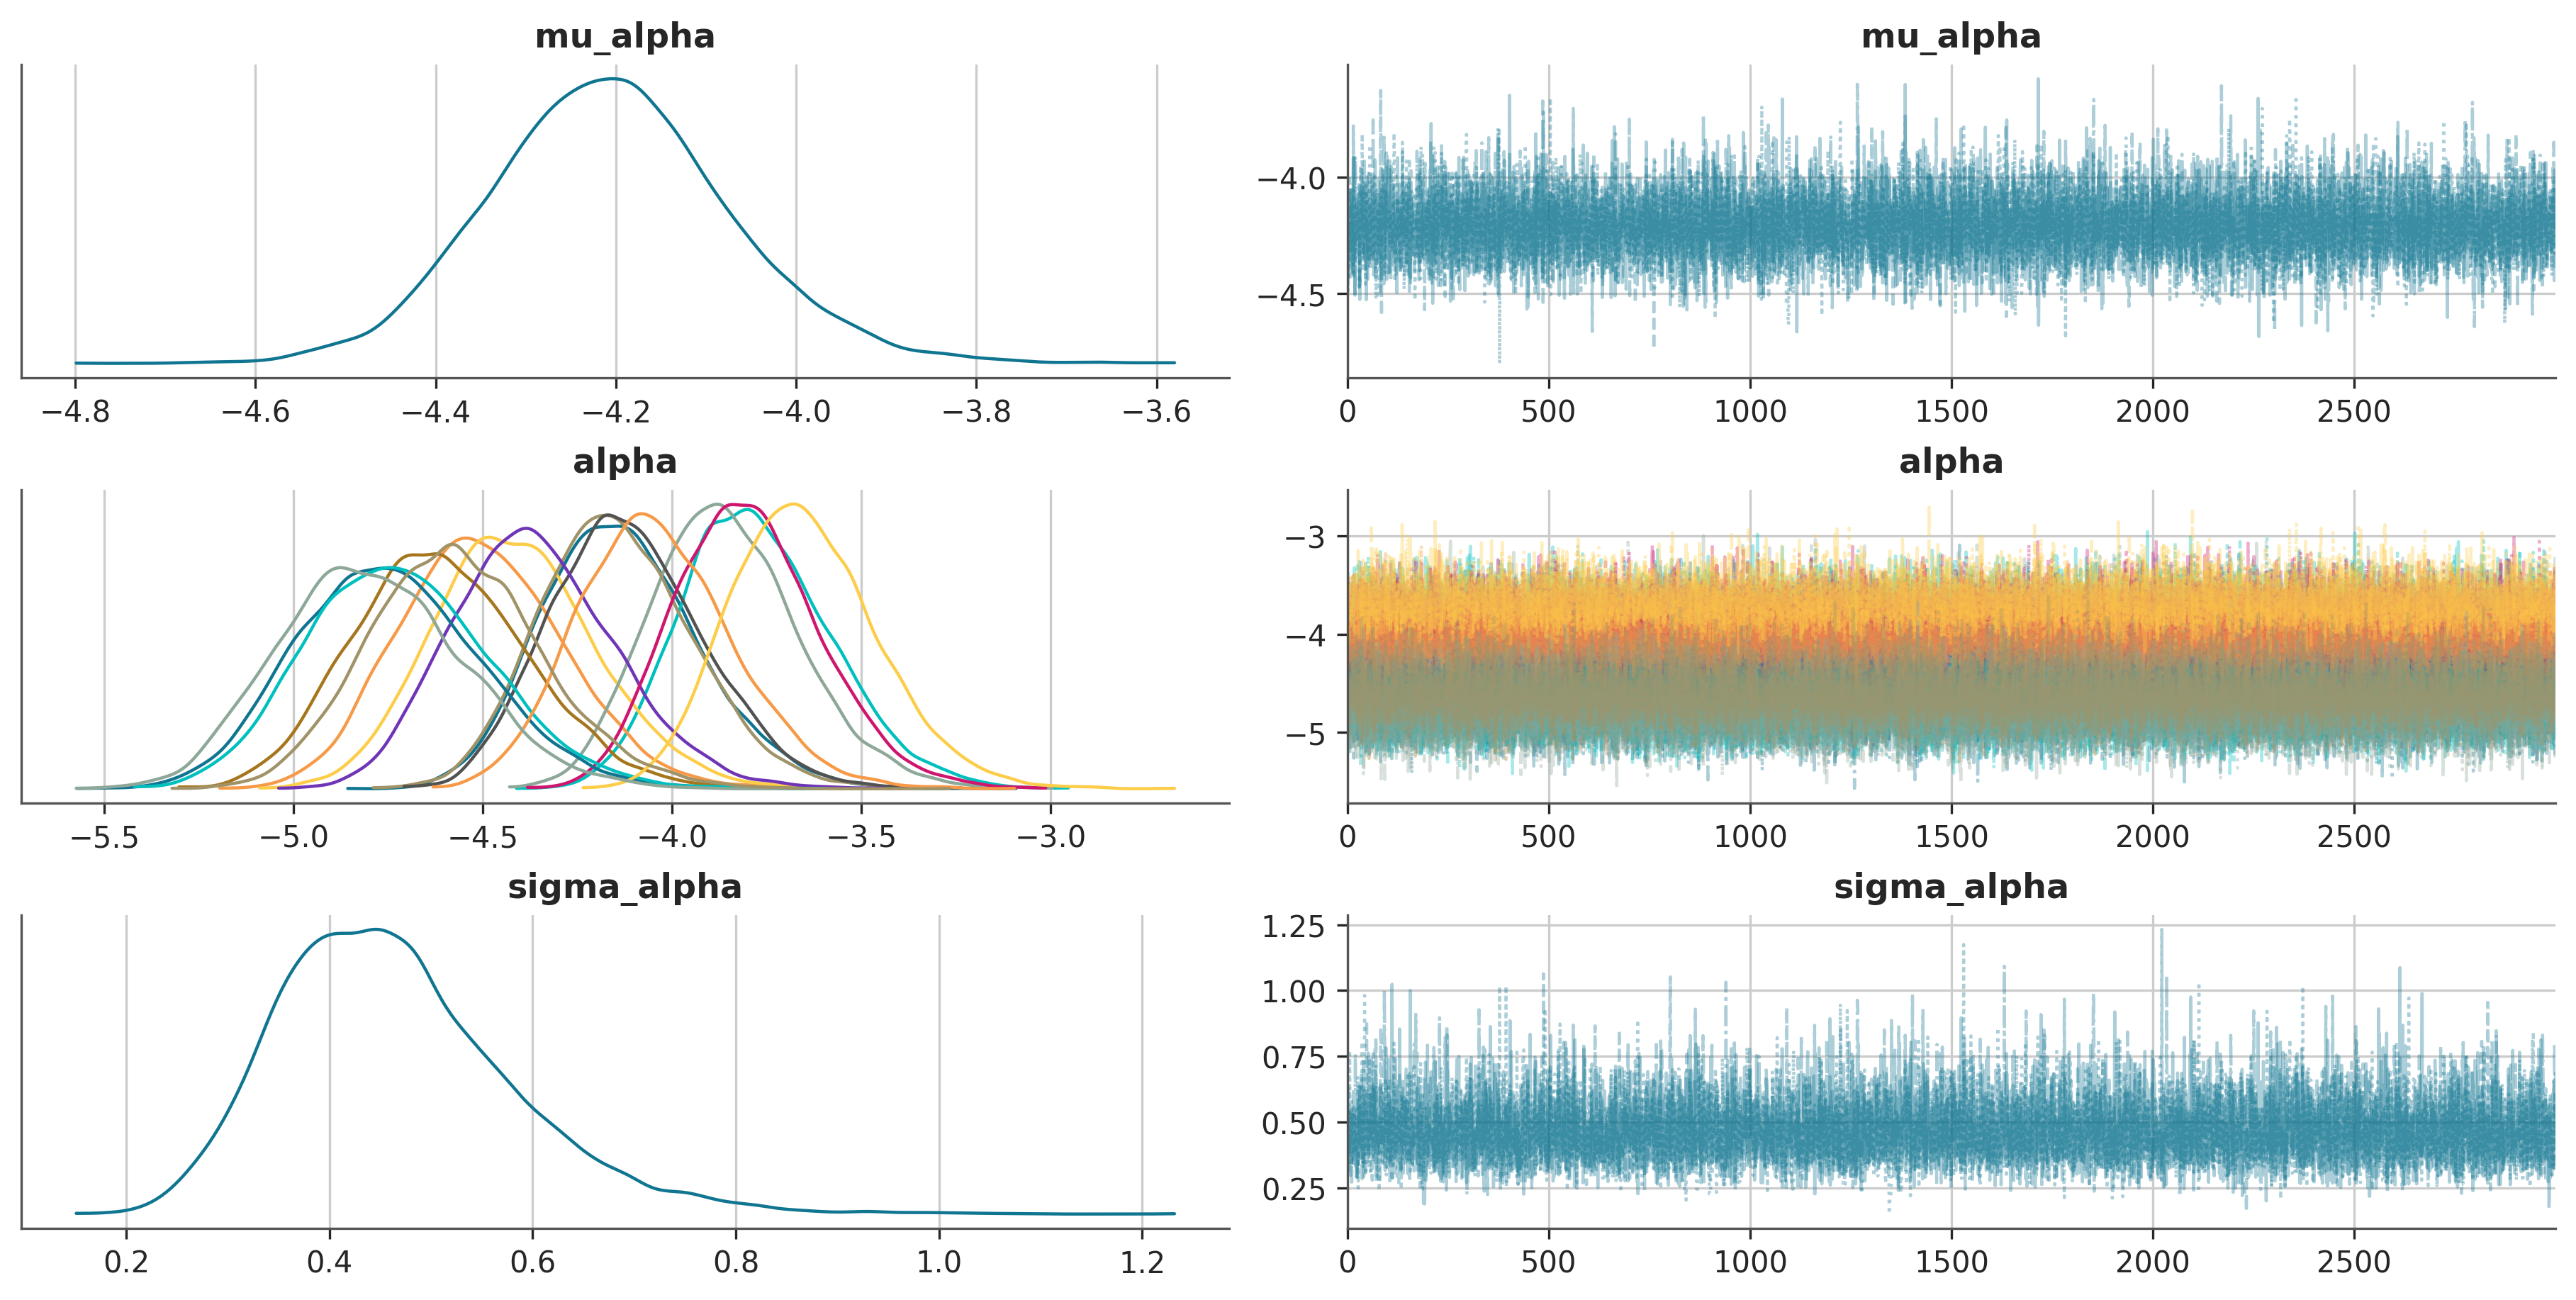

In [69]:
az.plot_trace(task_3_trace, combined=True)

### Posterior predictive checks 

In [76]:
# posterior predictive check 
with task_3_model:
    pm.sample_posterior_predictive(task_3_trace, extend_inferencedata=True, random_seed=42)

Sampling: [error]


Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00━━━━━━━━━━━━━━  65% 0:00:01 / 0:00:00


We will plot using the [`plot_ppc_dist`](https://python.arviz.org/projects/plots/en/latest/api/generated/arviz_plots.plot_ppc_dist.html#arviz_plots.plot_ppc_dist) function: 

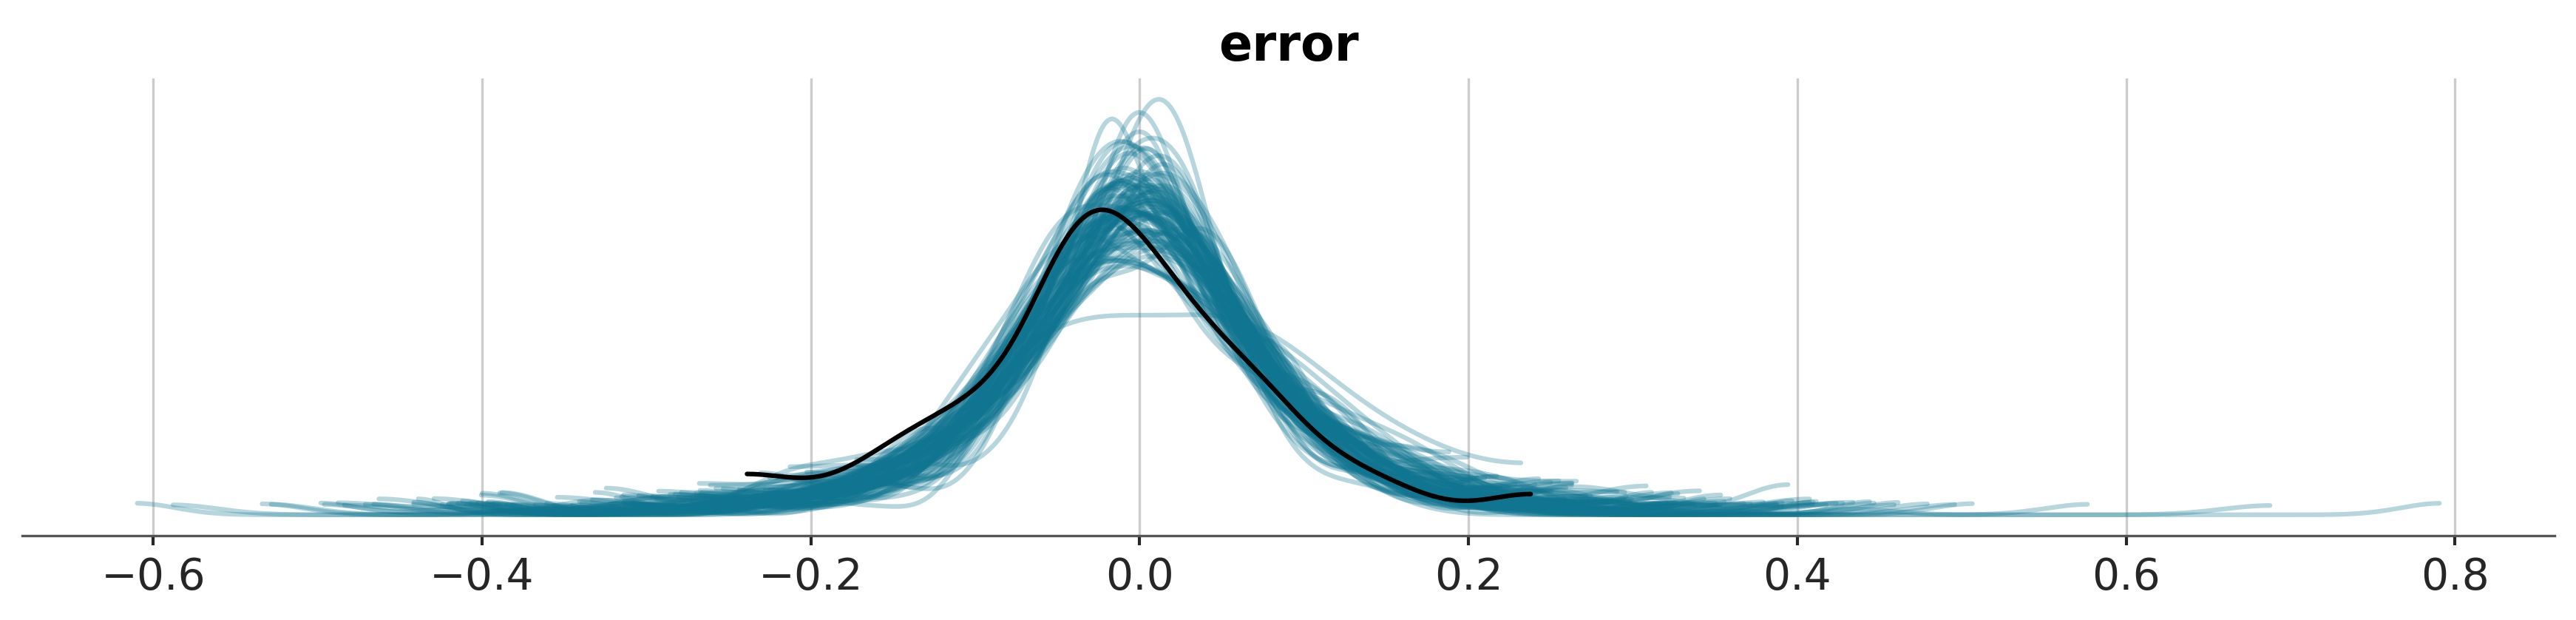

In [81]:
az.style.use("arviz-docgrid")
pc = azp.plot_ppc_dist(
    task_3_trace,
    num_samples=100,
    # backend="none",
)
pc.show()

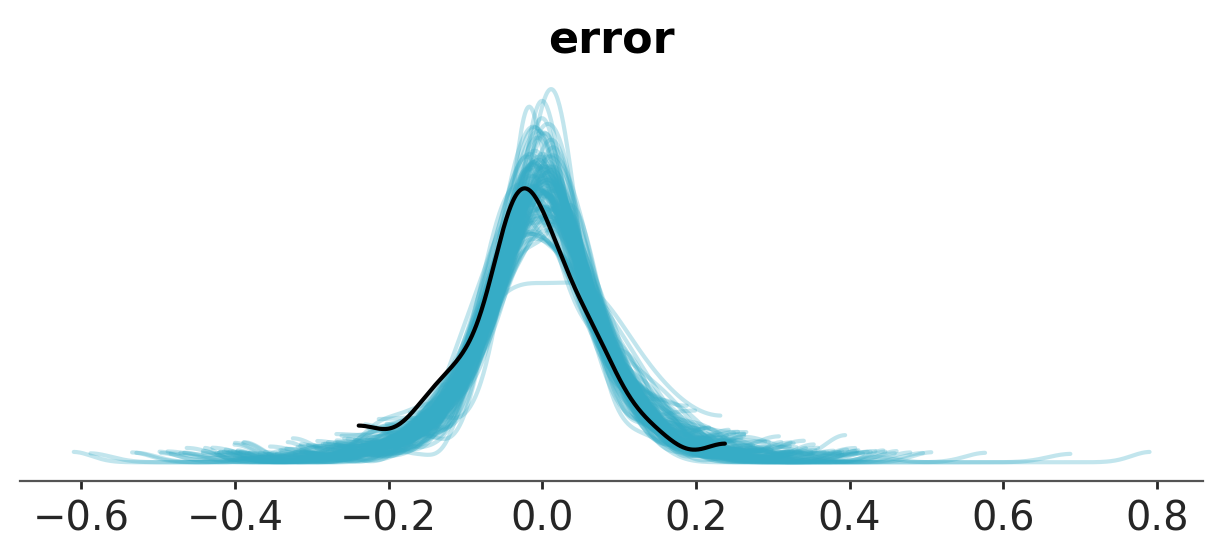

In [90]:
azp.style.use("arviz-variat")
pc = azp.plot_ppc_dist(
    task_3_trace,
    num_samples=100,
    backend="matplotlib",
)
pc.show()

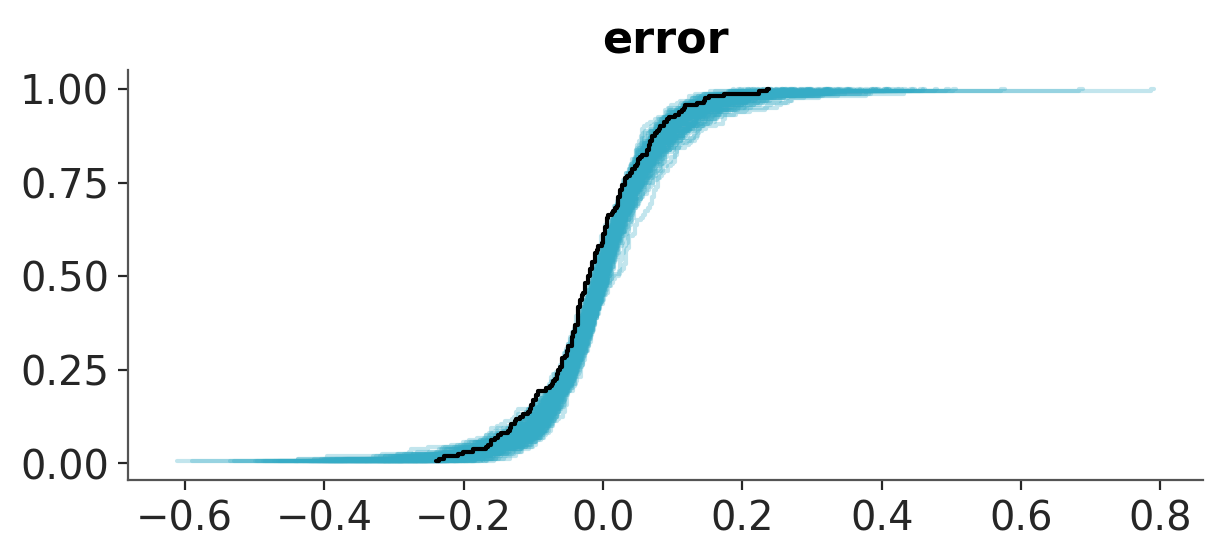

In [91]:
azp.style.use("arviz-variat")
pc = azp.plot_ppc_dist(
    task_3_trace,
    num_samples=100,
    backend="matplotlib",
    kind="ecdf"
)
pc.show()

Comparing this to the posterior predictive check generated by `bayesplot` in `R`, the one in `R` seems to have an extended long line ...? WHY?? 

Next we plot the **pit_ecdf** plot: 

(See more information in this [documentation](https://arviz-devs.github.io/EABM/Chapters/Prior_posterior_predictive_checks.html#pit-ecdfs) for posterior and prior predictive checks)

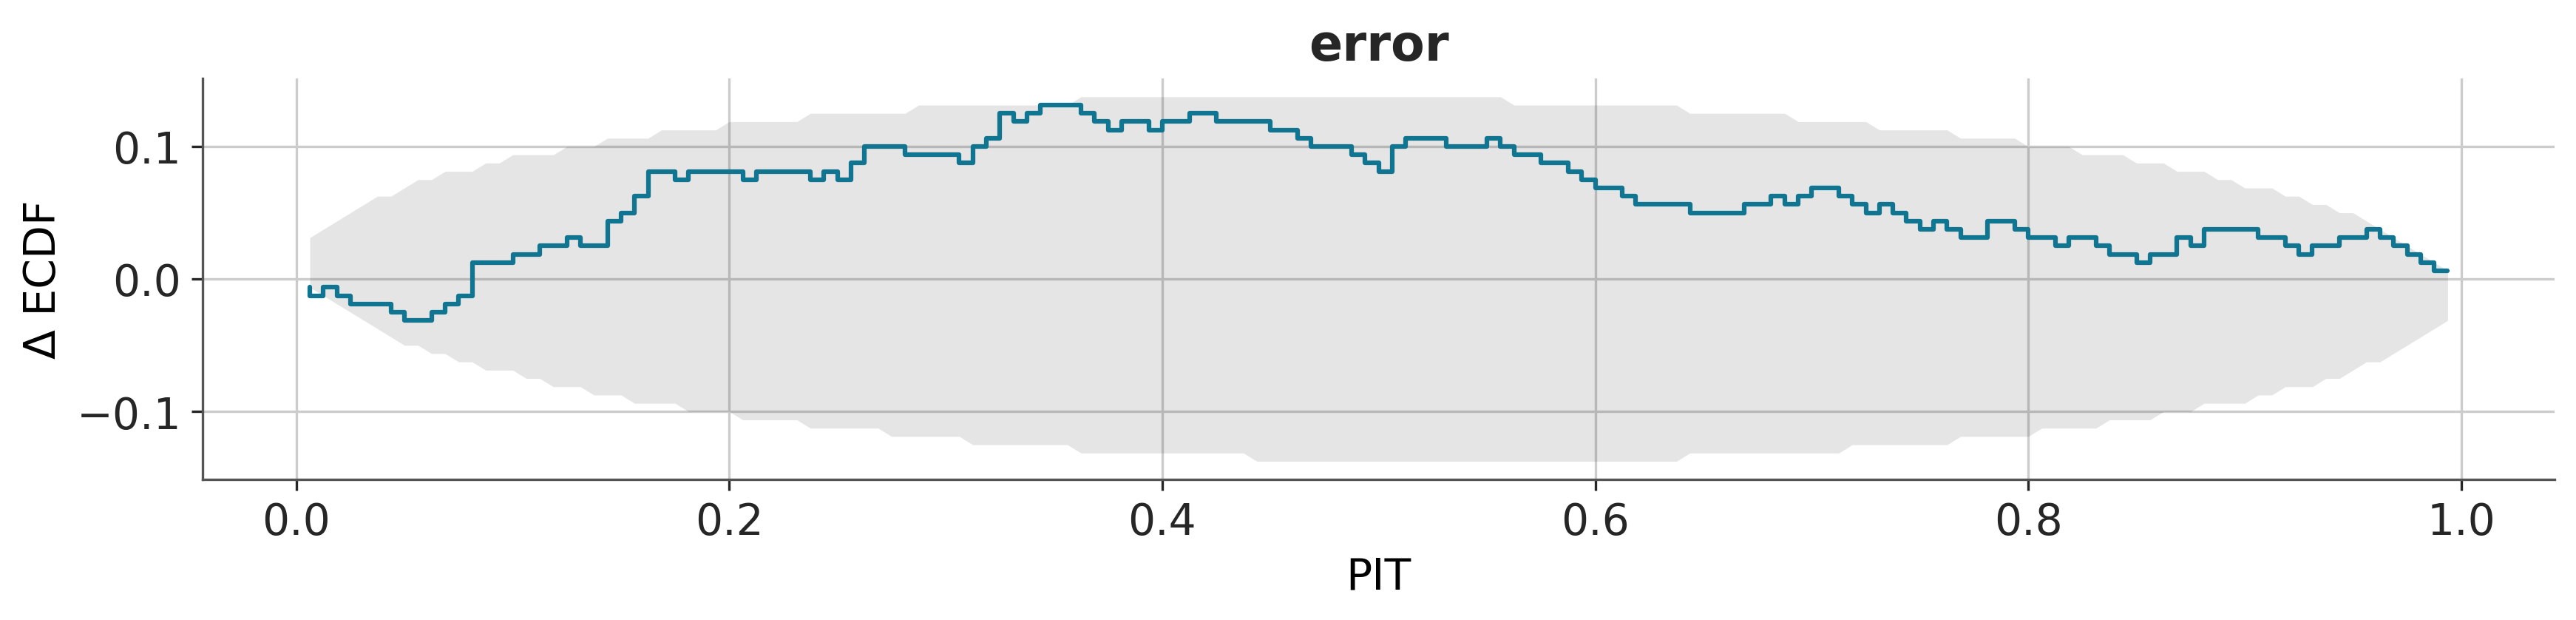

In [99]:
az.style.use("arviz-docgrid")
pc = azp.plot_ppc_pit(
    task_3_trace,
    # backend="none",
)
pc.show()

What I don't get is that, why is it plotting Delta ECDF and not just plain ECDF ...?? 

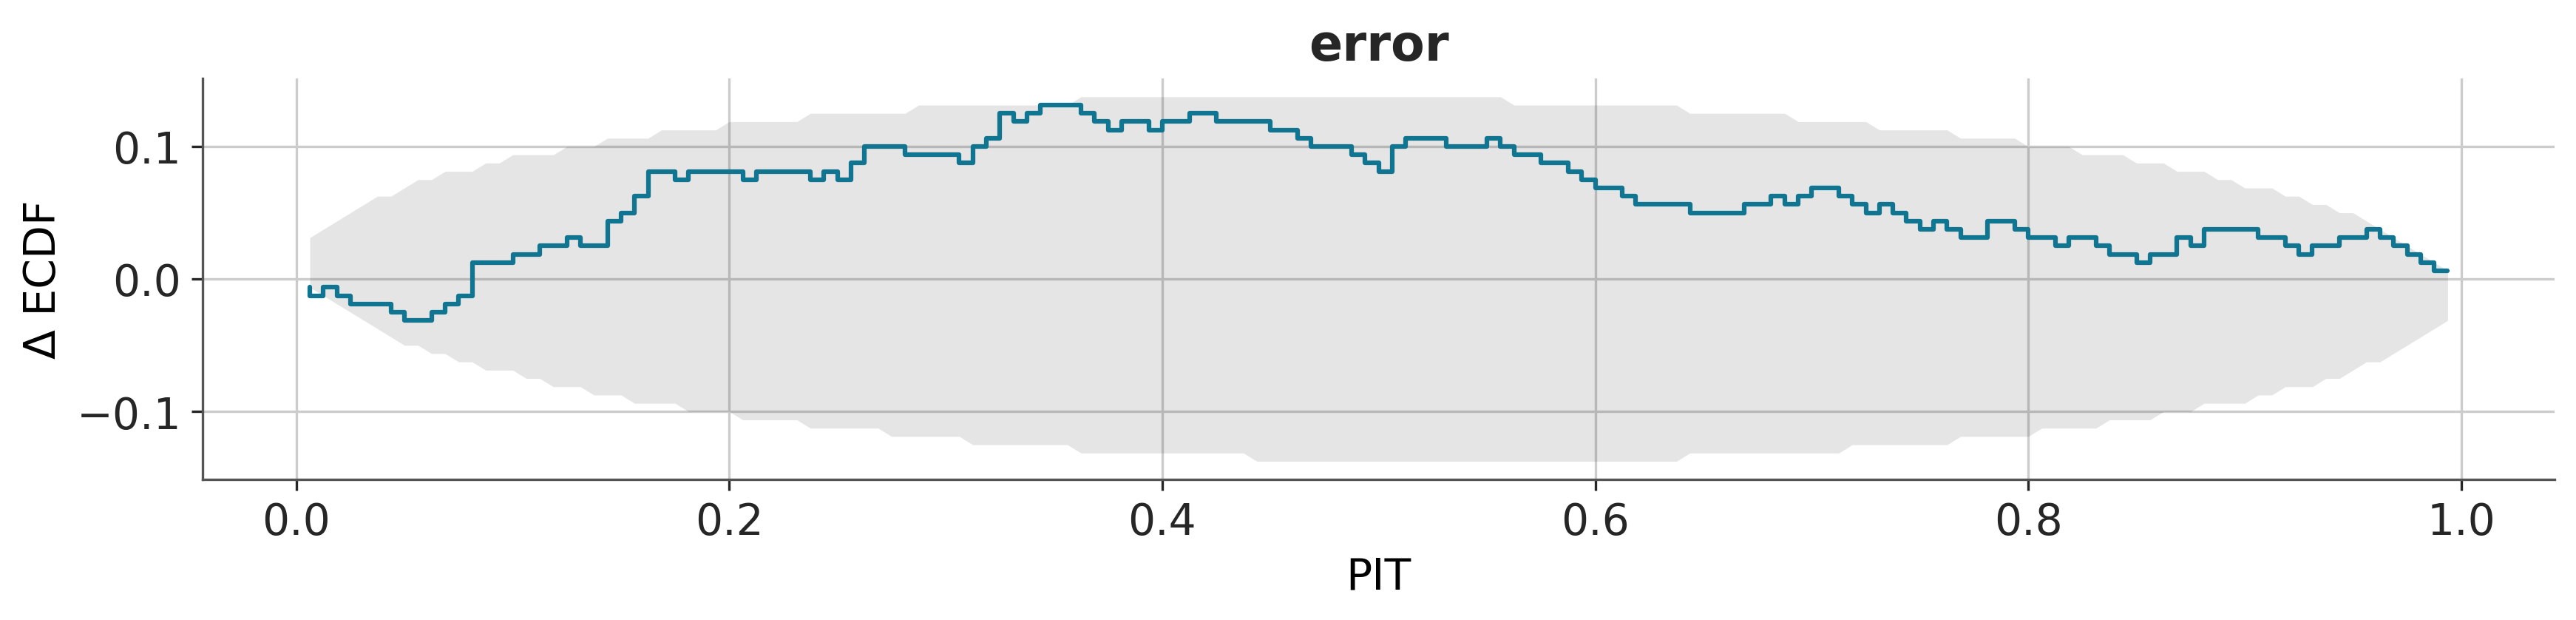

In [98]:
az.style.use("arviz-docgrid")
pc = azp.plot_ppc_pit(
    task_3_trace,
    coverage=False
    # backend="none",
)
pc.show()

In [108]:
# save the fitted model 

task_3_trace.to_netcdf(filename="../fitted_models/task3.nc")


'../fitted_models/task3.nc'